In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import scipy.stats as plt


In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\MLR_ASSIGNMENT\Advertising dataset (1).csv")
df

,Unnamed: 0,TV,radio,newspaper,sales
0,0,230.1,37.8,69.2,22.1
1,1,44.5,39.3,45.1,10.4
2,2,17.2,45.9,69.3,9.3
3,3,151.5,41.3,58.5,18.5
4,4,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7.6
196,196,94.2,4.9,8.1,9.7
197,197,177.0,9.3,6.4,12.8
198,198,283.6,42.0,66.2,25.5


In [3]:
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
# Drop the unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df=df.drop('Unnamed: 0',axis=1)


In [7]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [8]:
df.shape

(200, 4)

In [9]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


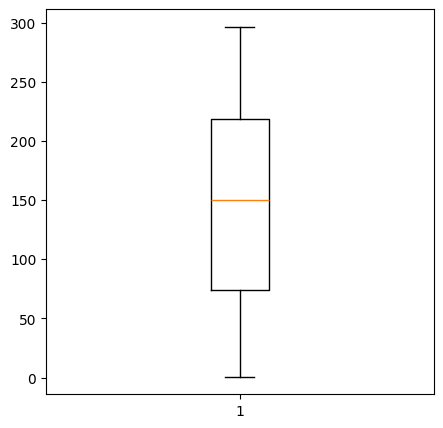

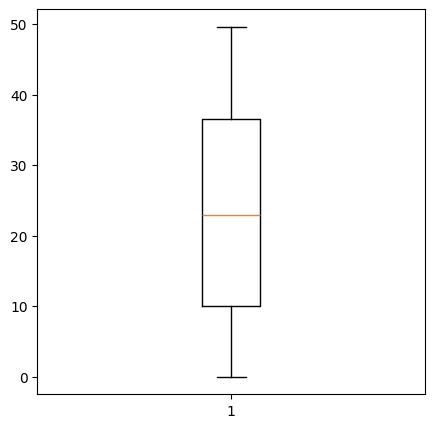

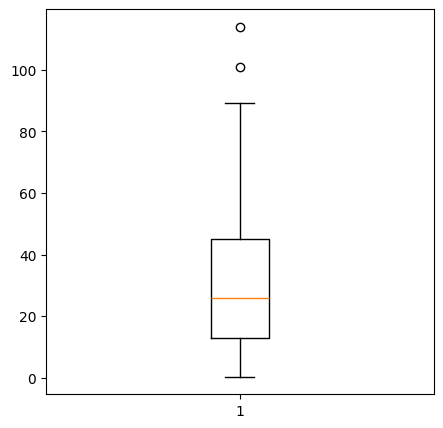

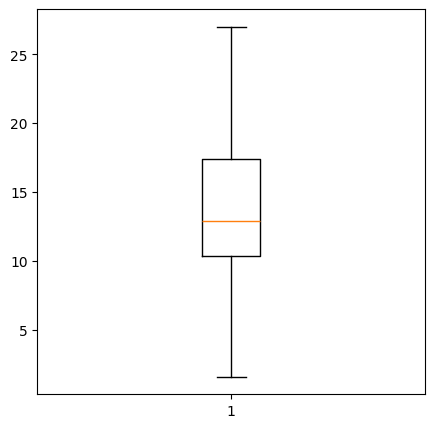

In [11]:
import matplotlib.pylab as plt
for i in df.columns:
    plt.figure(figsize=(5,5))
    plt.boxplot(df[i])
    # plt.tile()
    plt.show()

In [12]:
cor=df.corr()
cor.sort_values(by='sales',ascending=False)

,TV,radio,newspaper,sales
sales,0.782224,0.576223,0.228299,1.000000
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299


<Axes: >

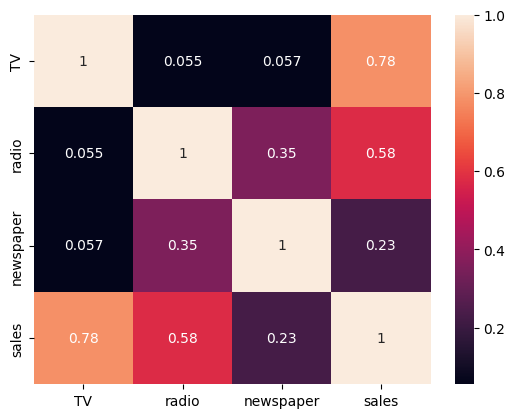

In [13]:
sns.heatmap(cor,annot=True)

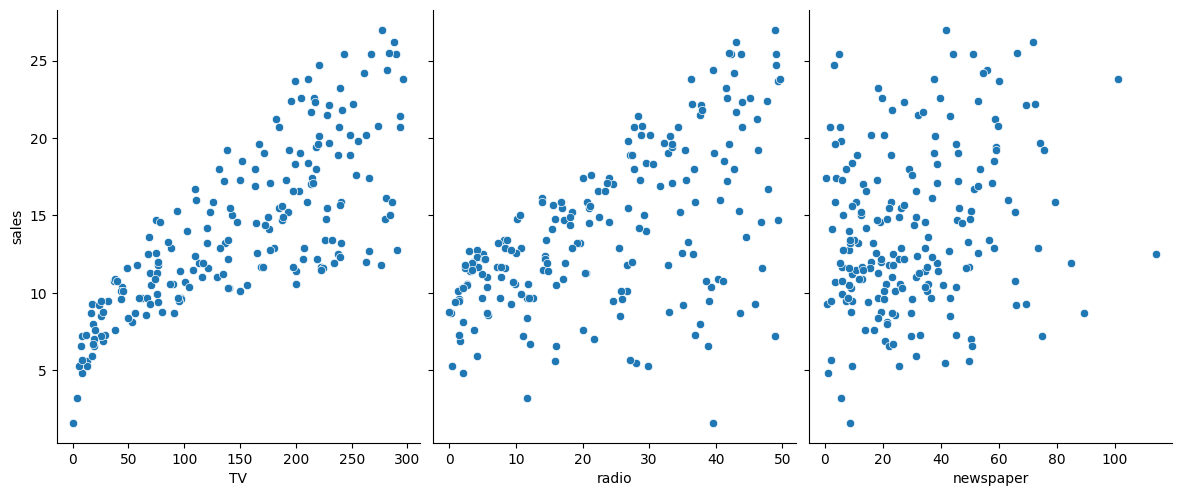

In [14]:
sns.pairplot(df,x_vars=['TV','radio','newspaper'],y_vars='sales',height=5,aspect=0.8)
plt.show()


In [15]:

# 2. Prepare data for regression
x=df[['TV','radio','newspaper']]
y=df['sales']


In [16]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [19]:
#add constant for statmodel
#split data (80% train, 20% test)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train_sm=sm.add_constant(x_train)
x_test_sm=sm.add_constant(x_test)


In [20]:
full_model=sm.OLS(y_train,x_train_sm).fit()
print("\nFull model summary (stats model on full data ):")
print(full_model.summary())


Full model summary (stats model on full data ):
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     446.6
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           2.53e-76
Time:                        13:26:01   Log-Likelihood:                -306.64
No. Observations:                 160   AIC:                             621.3
Df Residuals:                     156   BIC:                             633.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [23]:

# Coefficients from full model
print("\nEstimation regression equation:")
print(f"sales={full_model.params['const']:.4f}+{full_model.params['TV']:.4f}*TV+"
      f"{full_model.params['radio']:.4f}*radio +{full_model.params['newspaper']:.4f}*newspaper")



Estimation regression equation:
sales=2.9791+0.0447*TV+0.1892*radio +0.0028*newspaper


In [24]:
# R square
print(f"\nR-square:{full_model.rsquared:.4f}")

# model significance
print(f"\nOverall F-Statistic:{full_model.fvalue:.2f},p-value:{full_model.f_pvalue:.4f}")



R-square:0.8957

Overall F-Statistic:446.57,p-value:0.0000


In [ ]:
#4. evaluation on test set (using sklearn-style)
y_pred_test = full_model.predict(x_test_sm)
mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(f"\nMSE (test):{mse:.4f}")
print(f"RMSE (test):{rmse:.4f}")

In [26]:
# 5. Predictions
new_scenarios =pd.DataFrame({
    'const':[1,1],
    "TV":[200,300],
    "radio":[40,20],
    "newspaper":[20,50]
})
prediction=full_model.predict(new_scenarios)
print("\npredictions")
print(f"a) TV=200,radio=40,newspaper=20:sales\u2248 {prediction[0]:.2f}")
print(f"b) TV=100, radio=20, newspaper=50: Sales \u2248 {prediction[1]:.2f}")


predictions
a) TV=200,radio=40,newspaper=20:sales≈ 19.55
b) TV=100, radio=20, newspaper=50: Sales ≈ 20.32
